In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("\nFOLDER:", root)

    if files:
        print("FILES:", files[:10])
        print("NUMBER OF FILES:", len(files))

In [ ]:
import os

BASE_PATH = "/kaggle/input/datasets/venyah/deepshield"

REAL_PATH = os.path.join(BASE_PATH, "raw", "real")
FAKE_PATH = os.path.join(BASE_PATH, "raw", "fake")
VOICE_FAKE_PATH = os.path.join(BASE_PATH, "raw", "fake_voice_only")

print("Real videos:", len(os.listdir(REAL_PATH)))
print("Fake videos:", len(os.listdir(FAKE_PATH)))
print("Voice-only fake videos:", len(os.listdir(VOICE_FAKE_PATH)))

In [ ]:
import cv2
import os

test_video = os.path.join(
    REAL_PATH,
    "real_0001.mp4"
)

cap = cv2.VideoCapture(test_video)

if not cap.isOpened():
    print("ERROR: Could not open video")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame_count / fps if fps > 0 else 0

    print("Video opened successfully!")
    print("FPS:", fps)
    print("Frames:", frame_count)
    print("Resolution:", width, "x", height)
    print("Duration:", round(duration, 2), "seconds")

cap.release()

In [ ]:
real_videos = sorted([
    os.path.join(REAL_PATH, f)
    for f in os.listdir(REAL_PATH)
    if f.lower().endswith(".mp4")
])[:5]

fake_videos = sorted([
    os.path.join(FAKE_PATH, f)
    for f in os.listdir(FAKE_PATH)
    if f.lower().endswith(".mp4")
])[:5]

test_videos = real_videos + fake_videos

print("REAL VIDEOS:")
for v in real_videos:
    print(os.path.basename(v))

print("\nFAKE VIDEOS:")
for v in fake_videos:
    print(os.path.basename(v))

In [ ]:
!pip install -q librosa soundfile mediapipe

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy
import mediapipe as mp

print("All libraries imported successfully!")

In [ ]:
import os

OUTPUT_DIR = "/kaggle/working/deepshield_member3"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "audio"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "graphs"), exist_ok=True)

print("Output directory created successfully!")
print(OUTPUT_DIR)

In [ ]:
test_video = real_videos[0]

print("Testing video:")
print(test_video)

In [ ]:
import subprocess
import os

audio_file = os.path.join(
    OUTPUT_DIR,
    "audio",
    "test_real_01.wav"
)

command = [
    "ffmpeg",
    "-y",
    "-i", test_video,
    "-vn",
    "-ac", "1",
    "-ar", "16000",
    audio_file
]

result = subprocess.run(
    command,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

if os.path.exists(audio_file):
    print("Audio extraction successful!")
    print("Saved to:", audio_file)
else:
    print("Audio extraction failed.")
    print(result.stderr.decode()[-2000:])

In [ ]:
import librosa

audio, sr = librosa.load(
    audio_file,
    sr=16000,
    mono=True
)

print("Sampling rate:", sr)
print("Audio duration:", round(len(audio) / sr, 2), "seconds")
print("Number of samples:", len(audio))

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

In [ ]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficients")

plt.show()

In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# Calculate RMS energy
rms = librosa.feature.rms(
    y=audio,
    frame_length=2048,
    hop_length=512
)[0]

# Use the mean RMS as a simple preliminary threshold
threshold = np.mean(rms)

# 1 = likely speech/activity
# 0 = lower-energy/silence
speech_activity = (rms > threshold).astype(int)

# Convert frames to time
audio_times = librosa.frames_to_time(
    np.arange(len(speech_activity)),
    sr=sr,
    hop_length=512
)

print("Speech activity signal created.")
print("Number of audio frames:", len(speech_activity))
print("Estimated active frames:", np.sum(speech_activity))
print("Threshold:", threshold)

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(
    audio_times,
    speech_activity,
    drawstyle="steps-post"
)

plt.title("Preliminary Speech Activity Detection")
plt.xlabel("Time (seconds)")
plt.ylabel("Speech Activity")

plt.ylim(-0.1, 1.1)
plt.grid()

plt.show()

In [ ]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("MediaPipe Face Mesh initialized successfully!")

In [ ]:
!pip uninstall -y mediapipe
!pip install -q mediapipe==0.10.21

In [ ]:
import mediapipe as mp
import numpy as np
import cv2

print("MediaPipe:", mp.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Has mp.solutions:", hasattr(mp, "solutions"))

In [ ]:
!pip install -q mediapipe==0.10.21

In [ ]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

In [ ]:
!pip uninstall -y tensorflow tensorflow-cpu tensorflow-gpu \
    opencv-python opencv-python-headless opencv-contrib-python \
    mediapipe

!pip install -q \
    numpy==1.26.4 \
    protobuf==4.25.8 \
    opencv-python==4.11.0.86 \
    opencv-contrib-python==4.11.0.86 \
    mediapipe==0.10.21

In [1]:
import mediapipe as mp
import numpy as np
import cv2

print("MediaPipe:", mp.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Has mp.solutions:", hasattr(mp, "solutions"))

MediaPipe: 0.10.21
NumPy: 1.26.4
OpenCV: 4.11.0
Has mp.solutions: True


In [2]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("Face Mesh initialized successfully!")

Face Mesh initialized successfully!


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790246017.896678     211 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790246017.922650     213 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [3]:
UPPER_LIP = 13
LOWER_LIP = 14

print("Upper lip landmark:", UPPER_LIP)
print("Lower lip landmark:", LOWER_LIP)

Upper lip landmark: 13
Lower lip landmark: 14


In [4]:
import cv2
import numpy as np

mouth_signal = []
frame_times = []

cap = cv2.VideoCapture(test_video)

fps = cap.get(cv2.CAP_PROP_FPS)

print("FPS:", fps)

frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        landmarks = results.multi_face_landmarks[0].landmark

        upper = landmarks[UPPER_LIP]
        lower = landmarks[LOWER_LIP]

        mouth_opening = abs(lower.y - upper.y)

        mouth_signal.append(mouth_opening)
    else:
        mouth_signal.append(0)

    frame_times.append(frame_index / fps)

    frame_index += 1

cap.release()

mouth_signal = np.array(mouth_signal)
frame_times = np.array(frame_times)

print("Number of frames:", len(mouth_signal))
print("Duration:", frame_times[-1], "seconds")

NameError: name 'test_video' is not defined

In [5]:
import os

REAL_PATH = "/kaggle/input/datasets/venyah/deepshield/raw/real"
FAKE_PATH = "/kaggle/input/datasets/venyah/deepshield/raw/fake"

real_videos = sorted([
    os.path.join(REAL_PATH, f)
    for f in os.listdir(REAL_PATH)
    if f.endswith(".mp4")
])

fake_videos = sorted([
    os.path.join(FAKE_PATH, f)
    for f in os.listdir(FAKE_PATH)
    if f.endswith(".mp4")
])

test_video = real_videos[0]

print("Test video:", test_video)

Test video: /kaggle/input/datasets/venyah/deepshield/raw/real/real_0001.mp4


In [6]:
import cv2
import numpy as np

mouth_signal = []
frame_times = []

cap = cv2.VideoCapture(test_video)

fps = cap.get(cv2.CAP_PROP_FPS)

print("FPS:", fps)

frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        landmarks = results.multi_face_landmarks[0].landmark

        upper = landmarks[13]
        lower = landmarks[14]

        mouth_opening = abs(lower.y - upper.y)

        mouth_signal.append(mouth_opening)
    else:
        mouth_signal.append(0)

    frame_times.append(frame_index / fps)
    frame_index += 1

cap.release()

mouth_signal = np.array(mouth_signal)
frame_times = np.array(frame_times)

print("Number of frames:", len(mouth_signal))
print("Duration:", frame_times[-1], "seconds")

FPS: 25.0


W0000 00:00:1790246131.196661     213 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Number of frames: 115
Duration: 4.56 seconds


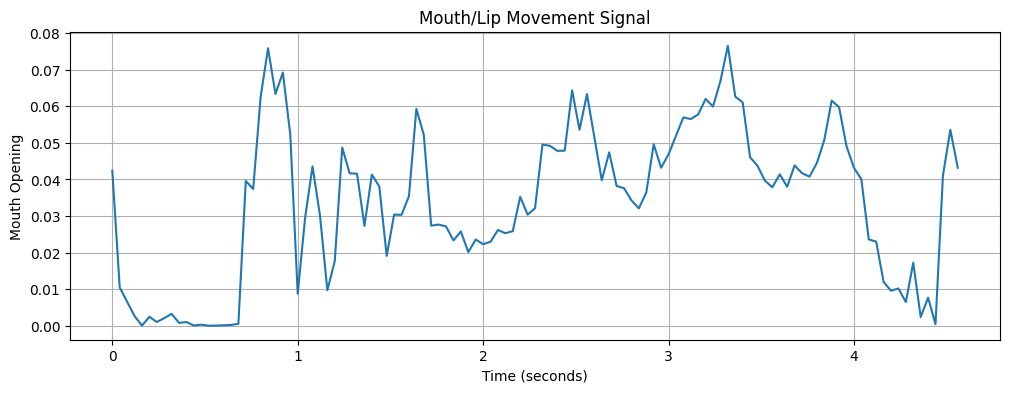

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(frame_times, mouth_signal)

plt.xlabel("Time (seconds)")
plt.ylabel("Mouth Opening")
plt.title("Mouth/Lip Movement Signal")
plt.grid()

plt.show()

In [8]:
# Interpolate mouth movement to the audio time points

mouth_interp = np.interp(
    audio_times,
    frame_times,
    mouth_signal
)

# Normalize mouth movement to 0–1
mouth_norm = (
    (mouth_interp - mouth_interp.min()) /
    (mouth_interp.max() - mouth_interp.min() + 1e-8)
)

print("Audio samples:", len(audio_times))
print("Aligned mouth samples:", len(mouth_norm))
print("Mouth range:", mouth_norm.min(), "to", mouth_norm.max())

NameError: name 'audio_times' is not defined

In [9]:
import librosa
import numpy as np

# Load audio from the same test video
audio, sr = librosa.load(test_video, sr=16000, mono=True)

print("Sampling rate:", sr)
print("Audio duration:", len(audio) / sr, "seconds")

# Calculate speech activity
rms = librosa.feature.rms(
    y=audio,
    frame_length=2048,
    hop_length=512
)[0]

threshold = np.mean(rms)

speech_activity = (rms > threshold).astype(int)

# Create time values for audio frames
audio_times = librosa.frames_to_time(
    np.arange(len(speech_activity)),
    sr=sr,
    hop_length=512
)

print("Number of audio frames:", len(audio_times))
print("Audio time range:", audio_times[0], "to", audio_times[-1])

/tmp/ipykernel_155/4191252944.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(test_video, sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sampling rate: 16000
Audio duration: 4.608 seconds
Number of audio frames: 145
Audio time range: 0.0 to 4.608


In [10]:
mouth_interp = np.interp(
    audio_times,
    frame_times,
    mouth_signal
)

mouth_norm = (
    (mouth_interp - mouth_interp.min()) /
    (mouth_interp.max() - mouth_interp.min() + 1e-8)
)

print("Audio samples:", len(audio_times))
print("Aligned mouth samples:", len(mouth_norm))
print("Mouth range:", mouth_norm.min(), "to", mouth_norm.max())

Audio samples: 145
Aligned mouth samples: 145
Mouth range: 0.0 to 0.9999998641948475


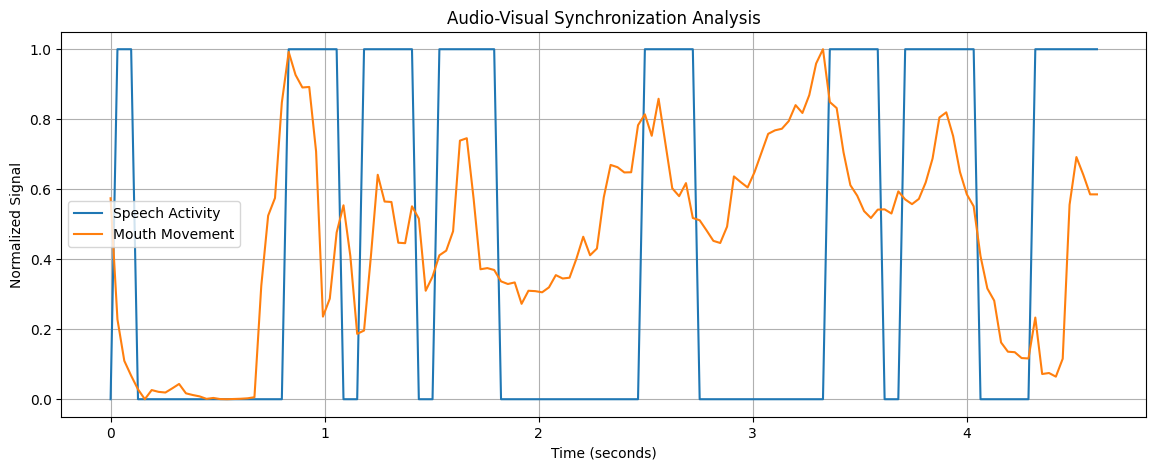

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    audio_times,
    speech_activity,
    label="Speech Activity"
)

plt.plot(
    audio_times,
    mouth_norm,
    label="Mouth Movement"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Signal")
plt.title("Audio-Visual Synchronization Analysis")

plt.legend()
plt.grid()

plt.show()

In [12]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    speech_activity.astype(float),
    mouth_norm
)

print("Audio-Lip Correlation:", correlation)
print("P-value:", p_value)

Audio-Lip Correlation: 0.2917640261440924
P-value: 0.0003698805169502897


In [13]:
sync_score = max(0, correlation) * 100

print(f"Preliminary Synchronization Score: {sync_score:.2f}/100")

Preliminary Synchronization Score: 29.18/100


In [14]:
import os
import subprocess
import librosa
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

results = []

# Use first 5 real and first 5 fake videos
videos_to_process = (
    [(v, "Real") for v in real_videos[:5]] +
    [(v, "Fake") for v in fake_videos[:5]]
)

for video_path, actual_class in videos_to_process:

    print("Processing:", os.path.basename(video_path))

    # ------------------------------------------------
    # 1. Extract audio
    # ------------------------------------------------

    video_name = os.path.splitext(
        os.path.basename(video_path)
    )[0]

    wav_path = os.path.join(
        OUTPUT_DIR,
        "audio",
        video_name + ".wav"
    )

    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        wav_path
    ]

    subprocess.run(
        command,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    # ------------------------------------------------
    # 2. Load audio
    # ------------------------------------------------

    audio, sr = librosa.load(
        wav_path,
        sr=16000,
        mono=True
    )

    # ------------------------------------------------
    # 3. Speech activity
    # ------------------------------------------------

    rms = librosa.feature.rms(
        y=audio,
        frame_length=2048,
        hop_length=512
    )[0]

    threshold = np.mean(rms)

    speech_activity = (
        rms > threshold
    ).astype(float)

    audio_times = librosa.frames_to_time(
        np.arange(len(speech_activity)),
        sr=sr,
        hop_length=512
    )

    # ------------------------------------------------
    # 4. Extract mouth movement
    # ------------------------------------------------

    mouth_signal = []
    frame_times = []

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        print("Invalid FPS. Skipping.")
        cap.release()
        continue

    frame_index = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        results_mp = face_mesh.process(rgb)

        if results_mp.multi_face_landmarks:

            landmarks = (
                results_mp.multi_face_landmarks[0].landmark
            )

            upper = landmarks[13]
            lower = landmarks[14]

            mouth_opening = abs(
                lower.y - upper.y
            )

            mouth_signal.append(mouth_opening)

        else:
            mouth_signal.append(0)

        frame_times.append(
            frame_index / fps
        )

        frame_index += 1

    cap.release()

    mouth_signal = np.array(mouth_signal)
    frame_times = np.array(frame_times)

    # ------------------------------------------------
    # 5. Align mouth signal with audio
    # ------------------------------------------------

    mouth_interp = np.interp(
        audio_times,
        frame_times,
        mouth_signal
    )

    mouth_norm = (
        (mouth_interp - mouth_interp.min()) /
        (mouth_interp.max() - mouth_interp.min() + 1e-8)
    )

    # ------------------------------------------------
    # 6. Calculate correlation
    # ------------------------------------------------

    try:

        correlation, p_value = pearsonr(
            speech_activity,
            mouth_norm
        )

        sync_score = max(0, correlation) * 100

    except Exception:

        correlation = np.nan
        p_value = np.nan
        sync_score = np.nan

    # ------------------------------------------------
    # 7. Store result
    # ------------------------------------------------

    results.append({
        "Video": video_name,
        "Actual Class": actual_class,
        "Correlation": correlation,
        "P-value": p_value,
        "Sync Score": sync_score
    })

    print(
        f"Correlation: {correlation:.4f} | "
        f"Sync Score: {sync_score:.2f}"
    )

# Create results table
results_df = pd.DataFrame(results)

results_df

Processing: real_0001.mp4


NameError: name 'OUTPUT_DIR' is not defined

In [15]:
import os

OUTPUT_DIR = "/kaggle/working/deepshield_member3"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "audio"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "graphs"), exist_ok=True)

print("Output directory ready:")
print(OUTPUT_DIR)

Output directory ready:
/kaggle/working/deepshield_member3


In [18]:
REAL_PATH = "/kaggle/input/datasets/venyah/deepshield/raw/real"
FAKE_PATH = "/kaggle/input/datasets/venyah/deepshield/raw/fake"

real_videos = sorted([
    os.path.join(REAL_PATH, f)
    for f in os.listdir(REAL_PATH)
    if f.endswith(".mp4")
])

fake_videos = sorted([
    os.path.join(FAKE_PATH, f)
    for f in os.listdir(FAKE_PATH)
    if f.endswith(".mp4")
])

print("Real videos:", len(real_videos))
print("Fake videos:", len(fake_videos))

Real videos: 100
Fake videos: 100


In [19]:
import os
import subprocess
import librosa
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

results = []

videos_to_process = (
    [(v, "Real") for v in real_videos[:5]] +
    [(v, "Fake") for v in fake_videos[:5]]
)

for video_path, actual_class in videos_to_process:

    video_name = os.path.splitext(
        os.path.basename(video_path)
    )[0]

    print("\nProcessing:", video_name)

    # 1. Extract audio
    wav_path = os.path.join(
        OUTPUT_DIR,
        "audio",
        video_name + ".wav"
    )

    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        wav_path
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    if result.returncode != 0:
        print("Audio extraction failed. Skipping.")
        continue

    # 2. Load audio
    audio, sr = librosa.load(
        wav_path,
        sr=16000,
        mono=True
    )

    # 3. Speech activity
    rms = librosa.feature.rms(
        y=audio,
        frame_length=2048,
        hop_length=512
    )[0]

    threshold = np.mean(rms)

    speech_activity = (
        rms > threshold
    ).astype(float)

    audio_times = librosa.frames_to_time(
        np.arange(len(speech_activity)),
        sr=sr,
        hop_length=512
    )

    # 4. Extract mouth movement
    mouth_signal = []
    frame_times = []

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        print("Invalid FPS. Skipping.")
        cap.release()
        continue

    frame_index = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        mp_result = face_mesh.process(rgb)

        if mp_result.multi_face_landmarks:

            landmarks = (
                mp_result.multi_face_landmarks[0].landmark
            )

            upper = landmarks[13]
            lower = landmarks[14]

            mouth_opening = abs(
                lower.y - upper.y
            )

            mouth_signal.append(mouth_opening)

        else:
            mouth_signal.append(0)

        frame_times.append(
            frame_index / fps
        )

        frame_index += 1

    cap.release()

    # 5. Convert to NumPy arrays
    mouth_signal = np.array(mouth_signal)
    frame_times = np.array(frame_times)

    if len(mouth_signal) < 2:
        print("Insufficient mouth data. Skipping.")
        continue

    # 6. Align mouth movement with audio
    mouth_interp = np.interp(
        audio_times,
        frame_times,
        mouth_signal
    )

    # Normalize
    mouth_norm = (
        (mouth_interp - mouth_interp.min()) /
        (mouth_interp.max() - mouth_interp.min() + 1e-8)
    )

    # 7. Calculate correlation
    try:
        correlation, p_value = pearsonr(
            speech_activity,
            mouth_norm
        )

        sync_score = max(0, correlation) * 100

    except Exception:
        correlation = np.nan
        p_value = np.nan
        sync_score = np.nan

    # 8. Store result
    results.append({
        "Video": video_name,
        "Actual Class": actual_class,
        "Correlation": correlation,
        "P-value": p_value,
        "Sync Score": sync_score
    })

    print(
        f"Correlation: {correlation:.4f} | "
        f"Sync Score: {sync_score:.2f}/100"
    )

# Create final table
results_df = pd.DataFrame(results)

print("\n========== FINAL RESULTS ==========")
display(results_df)


Processing: real_0001
Correlation: 0.2898 | Sync Score: 28.98/100

Processing: real_0002
Correlation: 0.3002 | Sync Score: 30.02/100

Processing: real_0003
Correlation: 0.1136 | Sync Score: 11.36/100

Processing: real_0004
Correlation: 0.0647 | Sync Score: 6.47/100

Processing: real_0005
Correlation: 0.0267 | Sync Score: 2.67/100

Processing: fake_0001
Correlation: -0.3084 | Sync Score: 0.00/100

Processing: fake_0002
Correlation: 0.0663 | Sync Score: 6.63/100

Processing: fake_0003
Correlation: -0.3370 | Sync Score: 0.00/100

Processing: fake_0004
Correlation: 0.1057 | Sync Score: 10.57/100

Processing: fake_0005
Correlation: -0.1225 | Sync Score: 0.00/100

========== FINAL RESULTS ==========


,Video,Actual Class,Correlation,P-value,Sync Score
0,real_0001,Real,0.289846,0.000406,28.984633
1,real_0002,Real,0.300215,0.000404,30.021523
2,real_0003,Real,0.113580,0.024705,11.358006
3,real_0004,Real,0.064701,0.272946,6.470123
4,real_0005,Real,0.026662,0.701571,2.666175
5,fake_0001,Fake,-0.308355,0.000043,0.000000
6,fake_0002,Fake,0.066335,0.321893,6.633511
7,fake_0003,Fake,-0.337021,0.000088,0.000000
8,fake_0004,Fake,0.105733,0.196324,10.573278
9,fake_0005,Fake,-0.122504,0.089653,0.000000


In [20]:
results_csv = os.path.join(
    OUTPUT_DIR,
    "member3_synchronization_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False
)

print("Results saved successfully:")
print(results_csv)

Results saved successfully:
/kaggle/working/deepshield_member3/member3_synchronization_results.csv


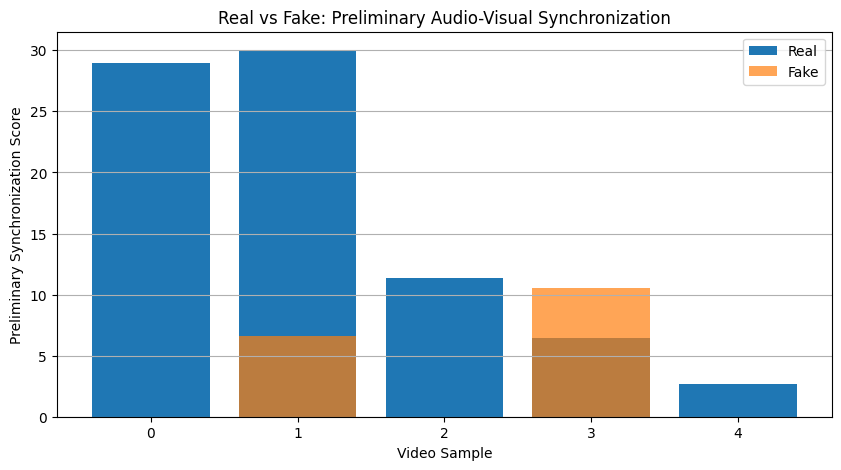

In [21]:
import matplotlib.pyplot as plt

real_scores = results_df[
    results_df["Actual Class"] == "Real"
]["Sync Score"]

fake_scores = results_df[
    results_df["Actual Class"] == "Fake"
]["Sync Score"]

plt.figure(figsize=(10, 5))

plt.bar(
    range(len(real_scores)),
    real_scores,
    label="Real"
)

plt.bar(
    range(len(fake_scores)),
    fake_scores,
    label="Fake",
    alpha=0.7
)

plt.xlabel("Video Sample")
plt.ylabel("Preliminary Synchronization Score")
plt.title("Real vs Fake: Preliminary Audio-Visual Synchronization")
plt.legend()
plt.grid(axis="y")

plt.show()

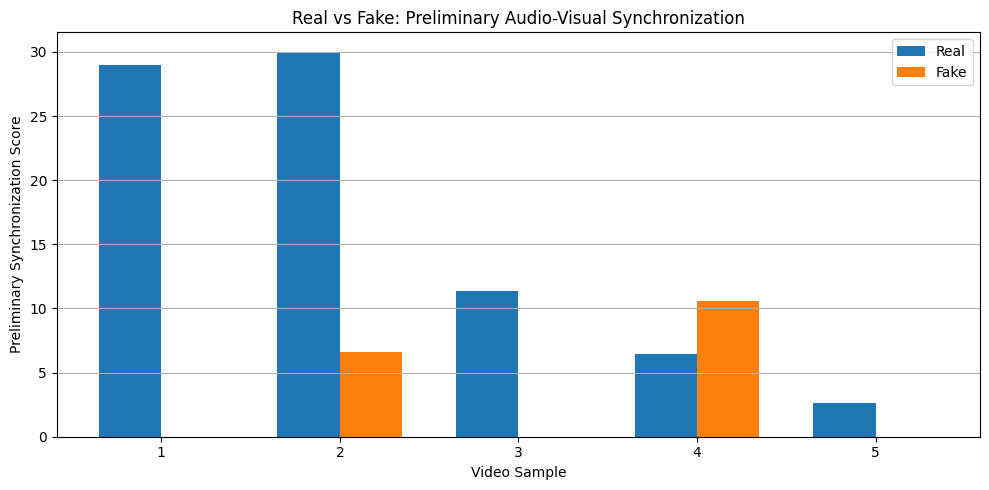

In [22]:
import matplotlib.pyplot as plt
import numpy as np

real_scores = results_df[
    results_df["Actual Class"] == "Real"
]["Sync Score"].values

fake_scores = results_df[
    results_df["Actual Class"] == "Fake"
]["Sync Score"].values

x = np.arange(5)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    real_scores,
    width,
    label="Real"
)

plt.bar(
    x + width/2,
    fake_scores,
    width,
    label="Fake"
)

plt.xlabel("Video Sample")
plt.ylabel("Preliminary Synchronization Score")
plt.title("Real vs Fake: Preliminary Audio-Visual Synchronization")

plt.xticks(
    x,
    ["1", "2", "3", "4", "5"]
)

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [23]:
import os
import subprocess
import librosa
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

print("Libraries loaded successfully")

Libraries loaded successfully


In [24]:
BASE_PATH = "/kaggle/input/datasets/venyah/deepshield"

REAL_PATH = os.path.join(
    BASE_PATH, "raw", "real"
)

FAKE_PATH = os.path.join(
    BASE_PATH, "raw", "fake"
)

VOICE_FAKE_PATH = os.path.join(
    BASE_PATH, "raw", "fake_voice_only"
)

print("Dataset paths ready")

Dataset paths ready


In [25]:
OUTPUT_DIR = "/kaggle/working/deepshield_member3"

AUDIO_DIR = os.path.join(
    OUTPUT_DIR, "audio"
)

GRAPH_DIR = os.path.join(
    OUTPUT_DIR, "graphs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Audio directory:", AUDIO_DIR)
print("Graph directory:", GRAPH_DIR)

Output directory: /kaggle/working/deepshield_member3
Audio directory: /kaggle/working/deepshield_member3/audio
Graph directory: /kaggle/working/deepshield_member3/graphs


In [26]:
real_videos = sorted([
    os.path.join(REAL_PATH, f)
    for f in os.listdir(REAL_PATH)
    if f.lower().endswith(".mp4")
])

fake_videos = sorted([
    os.path.join(FAKE_PATH, f)
    for f in os.listdir(FAKE_PATH)
    if f.lower().endswith(".mp4")
])

voice_fake_videos = sorted([
    os.path.join(VOICE_FAKE_PATH, f)
    for f in os.listdir(VOICE_FAKE_PATH)
    if f.lower().endswith(".mp4")
])

print("Real videos:", len(real_videos))
print("Fake videos:", len(fake_videos))
print("Fake voice-only videos:", len(voice_fake_videos))

print("TOTAL:", 
      len(real_videos) + 
      len(fake_videos) + 
      len(voice_fake_videos))

Real videos: 100
Fake videos: 100
Fake voice-only videos: 30
TOTAL: 230


In [27]:
all_videos = (
    [(v, "Real") for v in real_videos] +
    [(v, "Fake") for v in fake_videos] +
    [(v, "Fake Voice Only") for v in voice_fake_videos]
)

print("Total videos to process:", len(all_videos))

print("\nFirst 3:")
for item in all_videos[:3]:
    print(item)

print("\nLast 3:")
for item in all_videos[-3:]:
    print(item)

Total videos to process: 230

First 3:
('/kaggle/input/datasets/venyah/deepshield/raw/real/real_0001.mp4', 'Real')
('/kaggle/input/datasets/venyah/deepshield/raw/real/real_0002.mp4', 'Real')
('/kaggle/input/datasets/venyah/deepshield/raw/real/real_0003.mp4', 'Real')

Last 3:
('/kaggle/input/datasets/venyah/deepshield/raw/fake_voice_only/voice_0028.mp4', 'Fake Voice Only')
('/kaggle/input/datasets/venyah/deepshield/raw/fake_voice_only/voice_0029.mp4', 'Fake Voice Only')
('/kaggle/input/datasets/venyah/deepshield/raw/fake_voice_only/voice_0030.mp4', 'Fake Voice Only')


In [28]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("MediaPipe Face Mesh initialized")

MediaPipe Face Mesh initialized


W0000 00:00:1790247687.842646     422 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790247687.867702     421 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [29]:
RESULTS_CSV = os.path.join(
    OUTPUT_DIR,
    "full_dataset_synchronization_results.csv"
)

if os.path.exists(RESULTS_CSV):

    results_df = pd.read_csv(RESULTS_CSV)

    processed_videos = set(
        results_df["Video"].astype(str)
    )

    print("Existing results found.")
    print("Already processed:", len(processed_videos))

else:

    results_df = pd.DataFrame(
        columns=[
            "Video",
            "Actual Class",
            "Correlation",
            "P-value",
            "Sync Score"
        ]
    )

    processed_videos = set()

    print("Starting a new results file.")

print("Results file:", RESULTS_CSV)

Starting a new results file.
Results file: /kaggle/working/deepshield_member3/full_dataset_synchronization_results.csv


In [37]:
def process_video(video_path, actual_class):

    video_name = os.path.splitext(
        os.path.basename(video_path)
    )[0]

    print(f"\nProcessing: {video_name} | {actual_class}")

    # 1. Extract audio
    wav_path = os.path.join(
        AUDIO_DIR,
        video_name + ".wav"
    )

    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", "16000",
        wav_path
    ]

    ffmpeg_result = subprocess.run(
        command,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    if ffmpeg_result.returncode != 0:
        print("Audio extraction failed.")
        return None

    # 2. Load audio
    audio, sr = librosa.load(
        wav_path,
        sr=16000,
        mono=True
    )

    if len(audio) < 100:
        print("Audio too short.")
        return None

    # 3. Speech activity
    rms = librosa.feature.rms(
        y=audio,
        frame_length=2048,
        hop_length=512
    )[0]

    threshold = np.mean(rms)

    speech_activity = (
        rms > threshold
    ).astype(float)

    audio_times = librosa.frames_to_time(
        np.arange(len(speech_activity)),
        sr=sr,
        hop_length=512
    )

    # 4. Extract mouth movement
    mouth_signal = []
    frame_times = []

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        print("Invalid FPS.")
        cap.release()
        return None

    frame_index = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        mp_result = face_mesh.process(rgb)

        if mp_result.multi_face_landmarks:

            landmarks = (
                mp_result.multi_face_landmarks[0].landmark
            )

            upper = landmarks[13]
            lower = landmarks[14]

            mouth_opening = abs(
                lower.y - upper.y
            )

            mouth_signal.append(mouth_opening)

        else:
            mouth_signal.append(0)

        frame_times.append(
            frame_index / fps
        )

        frame_index += 1

    cap.release()

    mouth_signal = np.array(mouth_signal)
    frame_times = np.array(frame_times)

    if len(mouth_signal) < 2:
        print("Insufficient mouth data.")
        return None

    # 5. Align mouth movement with audio
    mouth_interp = np.interp(
        audio_times,
        frame_times,
        mouth_signal
    )

    # 6. Normalize mouth movement
    mouth_norm = (
        (mouth_interp - mouth_interp.min()) /
        (
            mouth_interp.max() -
            mouth_interp.min() +
            1e-8
        )
    )

    # 7. Calculate correlation
    try:

        correlation, p_value = pearsonr(
            speech_activity,
            mouth_norm
        )

        sync_score = max(
            0,
            correlation
        ) * 100

    except Exception as e:

        print("Correlation error:", e)

        correlation = np.nan
        p_value = np.nan
        sync_score = np.nan

    # 8. Return result
    result = {
        "Video": video_name,
        "Actual Class": actual_class,
        "Correlation": correlation,
        "P-value": p_value,
        "Sync Score": sync_score
    }

    print(
        f"Correlation: {correlation:.4f} | "
        f"Score: {sync_score:.2f}/100"
    )

    return result

In [38]:
test_result = process_video(
    real_videos[0],
    "Real"
)

print("\nTest result:")
print(test_result)


Processing: real_0001 | Real
Correlation: 0.2918 | Score: 29.18/100

Test result:
{'Video': 'real_0001', 'Actual Class': 'Real', 'Correlation': 0.2917640261440924, 'P-value': 0.0003698805169502897, 'Sync Score': 29.17640261440924}


In [39]:
if test_result is not None:

    results_df = pd.concat(
        [
            results_df,
            pd.DataFrame([test_result])
        ],
        ignore_index=True
    )

    processed_videos.add(
        test_result["Video"]
    )

    results_df.to_csv(
        RESULTS_CSV,
        index=False
    )

    print("Test result saved.")
    print("Rows currently saved:", len(results_df))

Test result saved.
Rows currently saved: 1


/tmp/ipykernel_155/2026171559.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat(


In [40]:
display(results_df)

,Video,Actual Class,Correlation,P-value,Sync Score
0,real_0001,Real,0.291764,0.00037,29.176403


In [41]:
for index, (video_path, actual_class) in enumerate(
    all_videos,
    start=1
):

    video_name = os.path.splitext(
        os.path.basename(video_path)
    )[0]

    # Skip videos already processed
    if video_name in processed_videos:

        print(
            f"[{index}/230] Already processed: "
            f"{video_name}"
        )

        continue

    print(
        f"\n========== {index}/230 =========="
    )

    result = process_video(
        video_path,
        actual_class
    )

    if result is not None:

        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame([result])
            ],
            ignore_index=True
        )

        processed_videos.add(
            video_name
        )

        # Save immediately after every video
        results_df.to_csv(
            RESULTS_CSV,
            index=False
        )

        print(
            f"Checkpoint saved: "
            f"{len(results_df)}/230"
        )

    else:

        print(
            f"{video_name} failed and was not saved."
        )

print("\n================================")
print("FULL DATASET PROCESSING COMPLETE")
print("Successfully processed:", len(results_df))
print("================================")

[1/230] Already processed: real_0001

========== 2/230 ==========

Processing: real_0002 | Real
Correlation: 0.3031 | Score: 30.31/100
Checkpoint saved: 2/230

========== 3/230 ==========

Processing: real_0003 | Real
Correlation: 0.1134 | Score: 11.34/100
Checkpoint saved: 3/230

========== 4/230 ==========

Processing: real_0004 | Real
Correlation: 0.0655 | Score: 6.55/100
Checkpoint saved: 4/230

========== 5/230 ==========

Processing: real_0005 | Real
Correlation: 0.0259 | Score: 2.59/100
Checkpoint saved: 5/230

========== 6/230 ==========

Processing: real_0006 | Real
Correlation: 0.1148 | Score: 11.48/100
Checkpoint saved: 6/230

========== 7/230 ==========

Processing: real_0007 | Real
Correlation: 0.1666 | Score: 16.66/100
Checkpoint saved: 7/230

========== 8/230 ==========

Processing: real_0008 | Real
Correlation: 0.1374 | Score: 13.74/100
Checkpoint saved: 8/230

========== 9/230 ==========

Processing: real_0009 | Real
Correlation: 0.1299 | Score: 12.99/100
Checkpoint sa

In [42]:
# Reload the final saved results
results_df = pd.read_csv(RESULTS_CSV)

print("Total processed:", len(results_df))

summary = results_df.groupby(
    "Actual Class"
).agg(
    Number_of_Videos=("Video", "count"),
    Mean_Correlation=("Correlation", "mean"),
    Mean_Sync_Score=("Sync Score", "mean"),
    Median_Correlation=("Correlation", "median"),
    Median_Sync_Score=("Sync Score", "median")
).reset_index()

display(summary)

Total processed: 230


,Actual Class,Number_of_Videos,Mean_Correlation,Mean_Sync_Score,Median_Correlation,Median_Sync_Score
0,Fake,100,0.015783,7.161215,-0.001858,0.000000
1,Fake Voice Only,30,0.042533,9.512770,0.066717,6.671749
2,Real,100,0.056180,9.373660,0.064826,6.482613


In [43]:
display(
    results_df.head(10)
)

,Video,Actual Class,Correlation,P-value,Sync Score
0,real_0001,Real,0.291764,0.000370,29.176403
1,real_0002,Real,0.303053,0.000353,30.305297
2,real_0003,Real,0.113412,0.024920,11.341197
3,real_0004,Real,0.065502,0.267042,6.550200
4,real_0005,Real,0.025888,0.709834,2.588822
5,real_0006,Real,0.114832,0.175128,11.483216
6,real_0007,Real,0.166649,0.032407,16.664936
7,real_0008,Real,0.137407,0.074832,13.740709
8,real_0009,Real,0.129947,0.067349,12.994660
9,real_0010,Real,-0.085228,0.282393,0.000000


In [44]:
print(
    results_df["Actual Class"].value_counts()
)

Actual Class
Real               100
Fake               100
Fake Voice Only     30
Name: count, dtype: int64


In [46]:
import pandas as pd
import os

# Load the complete results
RESULTS_CSV = "/kaggle/working/deepshield_member3/full_dataset_synchronization_results.csv"

results_df = pd.read_csv(RESULTS_CSV)

print("Total videos processed:", len(results_df))

# Summary by class
summary = results_df.groupby(
    "Actual Class"
).agg(
    Number_of_Videos=("Video", "count"),
    Mean_Correlation=("Correlation", "mean"),
    Mean_Sync_Score=("Sync Score", "mean"),
    Median_Correlation=("Correlation", "median"),
    Median_Sync_Score=("Sync Score", "median")
).reset_index()

display(summary)

Total videos processed: 230


,Actual Class,Number_of_Videos,Mean_Correlation,Mean_Sync_Score,Median_Correlation,Median_Sync_Score
0,Fake,100,0.015783,7.161215,-0.001858,0.000000
1,Fake Voice Only,30,0.042533,9.512770,0.066717,6.671749
2,Real,100,0.056180,9.373660,0.064826,6.482613


/tmp/ipykernel_155/168598126.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


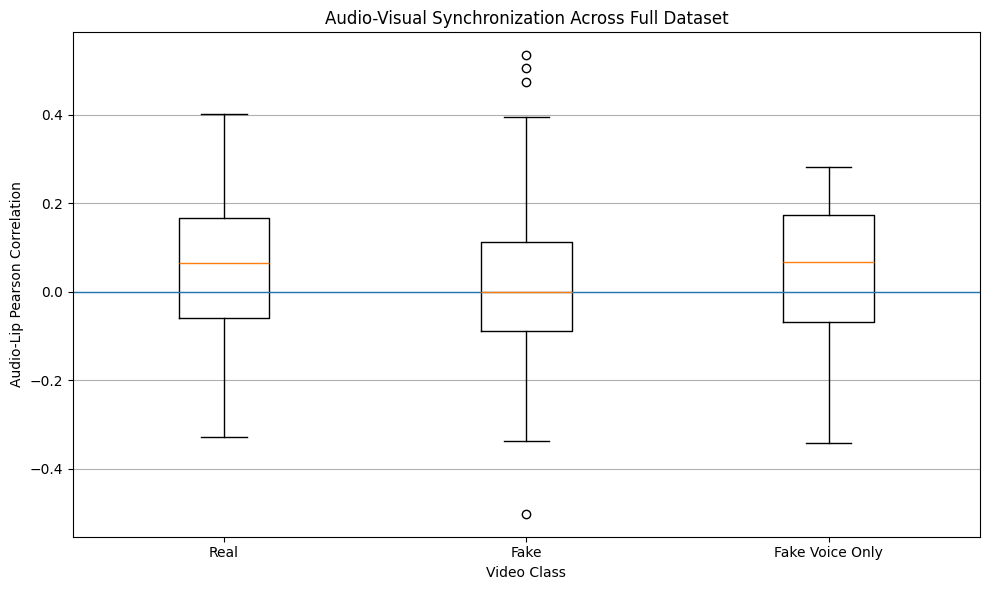

In [47]:
import matplotlib.pyplot as plt

classes = [
    "Real",
    "Fake",
    "Fake Voice Only"
]

correlation_data = [
    results_df[
        results_df["Actual Class"] == c
    ]["Correlation"].dropna()
    for c in classes
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    correlation_data,
    labels=classes
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Video Class")
plt.ylabel("Audio-Lip Pearson Correlation")
plt.title(
    "Audio-Visual Synchronization Across Full Dataset"
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

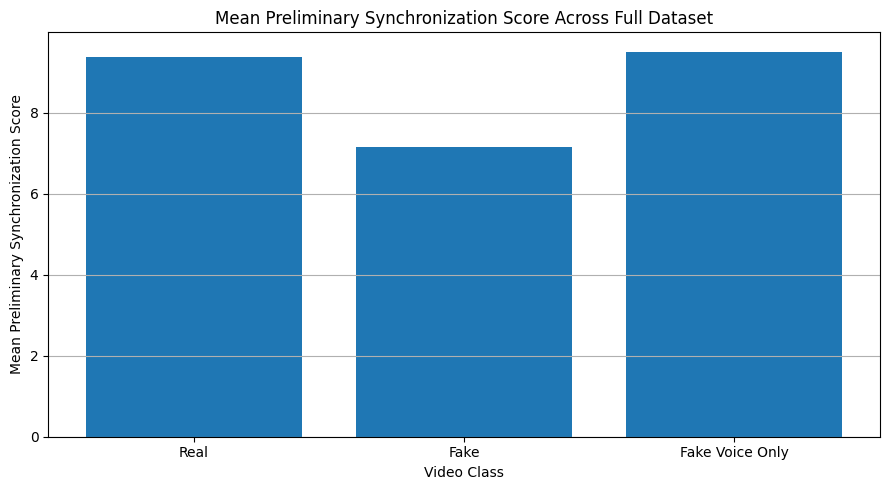

In [48]:
import matplotlib.pyplot as plt

classes = [
    "Real",
    "Fake",
    "Fake Voice Only"
]

mean_scores = [
    results_df[
        results_df["Actual Class"] == c
    ]["Sync Score"].mean()
    for c in classes
]

plt.figure(figsize=(9, 5))

plt.bar(
    classes,
    mean_scores
)

plt.xlabel("Video Class")
plt.ylabel("Mean Preliminary Synchronization Score")
plt.title(
    "Mean Preliminary Synchronization Score Across Full Dataset"
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

/tmp/ipykernel_155/35499004.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


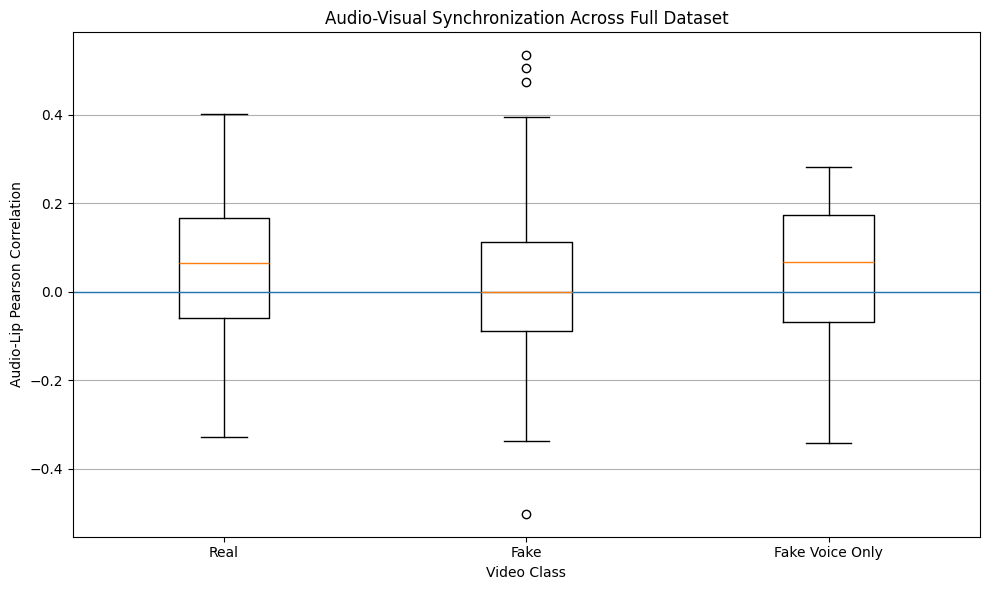

Saved: /kaggle/working/deepshield_member3/graphs/full_dataset_correlation_distribution.png


In [49]:
correlation_graph = os.path.join(
    GRAPH_DIR,
    "full_dataset_correlation_distribution.png"
)

classes = [
    "Real",
    "Fake",
    "Fake Voice Only"
]

correlation_data = [
    results_df[
        results_df["Actual Class"] == c
    ]["Correlation"].dropna()
    for c in classes
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    correlation_data,
    labels=classes
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Video Class")
plt.ylabel("Audio-Lip Pearson Correlation")
plt.title(
    "Audio-Visual Synchronization Across Full Dataset"
)

plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    correlation_graph,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", correlation_graph)

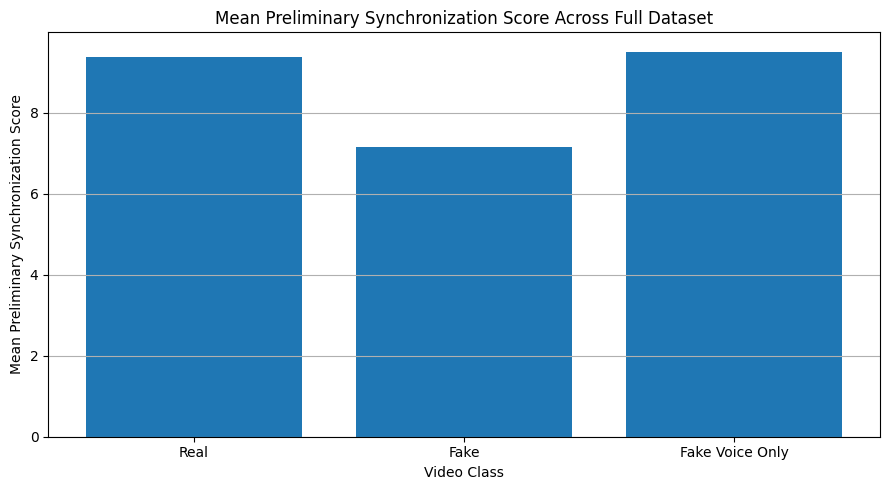

Saved: /kaggle/working/deepshield_member3/graphs/full_dataset_mean_sync_score.png


In [50]:
score_graph = os.path.join(
    GRAPH_DIR,
    "full_dataset_mean_sync_score.png"
)

mean_scores = [
    results_df[
        results_df["Actual Class"] == c
    ]["Sync Score"].mean()
    for c in classes
]

plt.figure(figsize=(9, 5))

plt.bar(
    classes,
    mean_scores
)

plt.xlabel("Video Class")
plt.ylabel("Mean Preliminary Synchronization Score")
plt.title(
    "Mean Preliminary Synchronization Score Across Full Dataset"
)

plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    score_graph,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", score_graph)

In [51]:
ppt_summary = summary.copy()

ppt_summary["Mean_Correlation"] = ppt_summary[
    "Mean_Correlation"
].round(4)

ppt_summary["Mean_Sync_Score"] = ppt_summary[
    "Mean_Sync_Score"
].round(2)

ppt_summary["Median_Correlation"] = ppt_summary[
    "Median_Correlation"
].round(4)

ppt_summary["Median_Sync_Score"] = ppt_summary[
    "Median_Sync_Score"
].round(2)

display(ppt_summary)

,Actual Class,Number_of_Videos,Mean_Correlation,Mean_Sync_Score,Median_Correlation,Median_Sync_Score
0,Fake,100,0.0158,7.16,-0.0019,0.00
1,Fake Voice Only,30,0.0425,9.51,0.0667,6.67
2,Real,100,0.0562,9.37,0.0648,6.48


In [52]:
PPT_SUMMARY_CSV = os.path.join(
    OUTPUT_DIR,
    "member3_ppt_summary.csv"
)

ppt_summary.to_csv(
    PPT_SUMMARY_CSV,
    index=False
)

print("PPT summary saved:")
print(PPT_SUMMARY_CSV)

PPT summary saved:
/kaggle/working/deepshield_member3/member3_ppt_summary.csv
